In [ ]:
!wget https://efrosgans.eecs.berkeley.edu/cyclegan/datasets/horse2zebra.zip
!unzip -q horse2zebra.zip
!rm horse2zebra.zip

--2026-07-20 11:23:30--  https://efrosgans.eecs.berkeley.edu/cyclegan/datasets/horse2zebra.zip
Resolving efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)... 128.32.244.190
Connecting to efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)|128.32.244.190|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 116867962 (111M) [application/zip]
Saving to: ‘horse2zebra.zip’

horse2zebra.zip     100%[===================>] 111.45M  17.4MB/s    in 7.5s    

2026-07-20 11:23:38 (14.8 MB/s) - ‘horse2zebra.zip’ saved [116867962/116867962]



In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import os
import glob
import itertools
import random

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
class ResidualBlock(nn.Module):
    def __init__(self, in_features):
        super(ResidualBlock, self).__init__()
        self.block = nn.Sequential(
            nn.ReflectionPad2d(1),
            nn.Conv2d(in_features, in_features, 3),
            nn.InstanceNorm2d(in_features),
            nn.ReLU(inplace=True),
            nn.ReflectionPad2d(1),
            nn.Conv2d(in_features, in_features, 3),
            nn.InstanceNorm2d(in_features)
        )

    def forward(self, x):
        return x + self.block(x)

class Generator(nn.Module):
    def __init__(self, input_nc=3, output_nc=3, n_residual_blocks=6):
        super(Generator, self).__init__()

        # Initial convolution block
        model = [
            nn.ReflectionPad2d(3),
            nn.Conv2d(input_nc, 64, 7),
            nn.InstanceNorm2d(64),
            nn.ReLU(inplace=True)
        ]

        # Downsampling
        in_features = 64
        out_features = in_features * 2
        for _ in range(2):
            model += [
                nn.Conv2d(in_features, out_features, 3, stride=2, padding=1),
                nn.InstanceNorm2d(out_features),
                nn.ReLU(inplace=True)
            ]
            in_features = out_features
            out_features = in_features * 2

        # Residual blocks
        for _ in range(n_residual_blocks):
            model += [ResidualBlock(in_features)]

        # Upsampling
        out_features = in_features // 2
        for _ in range(2):
            model += [
                nn.ConvTranspose2d(in_features, out_features, 3, stride=2, padding=1, output_padding=1),
                nn.InstanceNorm2d(out_features),
                nn.ReLU(inplace=True)
            ]
            in_features = out_features
            out_features = in_features // 2

        # Output layer
        model += [nn.ReflectionPad2d(3), nn.Conv2d(64, output_nc, 7), nn.Tanh()]
        self.model = nn.Sequential(*model)

    def forward(self, x):
        return self.model(x)

class Discriminator(nn.Module):
    def __init__(self, input_nc=3):
        super(Discriminator, self).__init__()

        model = [nn.Conv2d(input_nc, 64, 4, stride=2, padding=1), nn.LeakyReLU(0.2, inplace=True)]

        model += [
            nn.Conv2d(64, 128, 4, stride=2, padding=1),
            nn.InstanceNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, 4, stride=2, padding=1),
            nn.InstanceNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256, 512, 4, padding=1),
            nn.InstanceNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(512, 1, 4, padding=1)
        ]
        self.model = nn.Sequential(*model)

    def forward(self, x):
        return self.model(x)

In [ ]:
class HorseZebraDataset(Dataset):
    def __init__(self, root, transform=None, mode='train'):
        self.transform = transform
        self.files_A = sorted(glob.glob(os.path.join(root, f'{mode}A') + '/*.*'))
        self.files_B = sorted(glob.glob(os.path.join(root, f'{mode}B') + '/*.*'))

    def __getitem__(self, index):
        item_A = self.transform(Image.open(self.files_A[index % len(self.files_A)]).convert('RGB'))
        item_B = self.transform(Image.open(self.files_B[random.randint(0, len(self.files_B) - 1)]).convert('RGB'))
        return {'A': item_A, 'B': item_B}

    def __len__(self):
        return max(len(self.files_A), len(self.files_B))

# Transforms: Resize, Crop, Tensor, Normalize to [-1, 1]
transforms_ = transforms.Compose([
    transforms.Resize(286, Image.BICUBIC),
    transforms.RandomCrop(256),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataloader = DataLoader(HorseZebraDataset('horse2zebra', transform=transforms_, mode='train'),
                              batch_size=1, shuffle=True)
test_dataloader = DataLoader(HorseZebraDataset('horse2zebra', transform=transforms_, mode='test'),
                             batch_size=5, shuffle=False)

In [ ]:
# Initialize models
G_AB = Generator().to(device) # Horse to Zebra
G_BA = Generator().to(device) # Zebra to Horse
D_A = Discriminator().to(device)
D_B = Discriminator().to(device)

# Losses
criterion_GAN = nn.MSELoss()
criterion_cycle = nn.L1Loss()
criterion_identity = nn.L1Loss()

# Optimizers
optimizer_G = optim.Adam(itertools.chain(G_AB.parameters(), G_BA.parameters()), lr=0.0002, betas=(0.5, 0.999))
optimizer_D_A = optim.Adam(D_A.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D_B = optim.Adam(D_B.parameters(), lr=0.0002, betas=(0.5, 0.999))

# Training loop parameters
epochs = 5

In [ ]:
for epoch in range(epochs):
    for i, batch in enumerate(train_dataloader):
        # Real images
        real_A = batch['A'].to(device)
        real_B = batch['B'].to(device)

        # Real/Fake labels
        valid = torch.ones((real_A.size(0), 1, 30, 30), requires_grad=False).to(device)
        fake = torch.zeros((real_A.size(0), 1, 30, 30), requires_grad=False).to(device)

        # ------------------
        #  Train Generators
        # ------------------
        optimizer_G.zero_grad()

        # Identity loss
        loss_id_A = criterion_identity(G_BA(real_A), real_A)
        loss_id_B = criterion_identity(G_AB(real_B), real_B)
        loss_identity = (loss_id_A + loss_id_B) / 2

        # GAN loss
        fake_B = G_AB(real_A)
        loss_GAN_AB = criterion_GAN(D_B(fake_B), valid)
        fake_A = G_BA(real_B)
        loss_GAN_BA = criterion_GAN(D_A(fake_A), valid)
        loss_GAN = (loss_GAN_AB + loss_GAN_BA) / 2

        # Cycle loss
        recov_A = G_BA(fake_B)
        loss_cycle_A = criterion_cycle(recov_A, real_A)
        recov_B = G_AB(fake_A)
        loss_cycle_B = criterion_cycle(recov_B, real_B)
        loss_cycle = (loss_cycle_A + loss_cycle_B) / 2

        # Total G loss
        loss_G = loss_GAN + 10.0 * loss_cycle + 5.0 * loss_identity
        loss_G.backward()
        optimizer_G.step()

        # -----------------------
        #  Train Discriminator A
        # -----------------------
        optimizer_D_A.zero_grad()
        loss_real = criterion_GAN(D_A(real_A), valid)
        loss_fake = criterion_GAN(D_A(fake_A.detach()), fake)
        loss_D_A = (loss_real + loss_fake) / 2
        loss_D_A.backward()
        optimizer_D_A.step()

        # -----------------------
        #  Train Discriminator B
        # -----------------------
        optimizer_D_B.zero_grad()
        loss_real = criterion_GAN(D_B(real_B), valid)
        loss_fake = criterion_GAN(D_B(fake_B.detach()), fake)
        loss_D_B = (loss_real + loss_fake) / 2
        loss_D_B.backward()
        optimizer_D_B.step()

    print(f"[Epoch {epoch}/{epochs}] [D loss: {(loss_D_A + loss_D_B).item():.4f}] [G loss: {loss_G.item():.4f}]")

[Epoch 0/5] [D loss: 0.3520] [G loss: 3.1989]
[Epoch 1/5] [D loss: 0.5865] [G loss: 3.0119]
[Epoch 2/5] [D loss: 0.9028] [G loss: 3.3465]
[Epoch 3/5] [D loss: 0.6414] [G loss: 2.6816]
[Epoch 4/5] [D loss: 0.3072] [G loss: 2.7221]


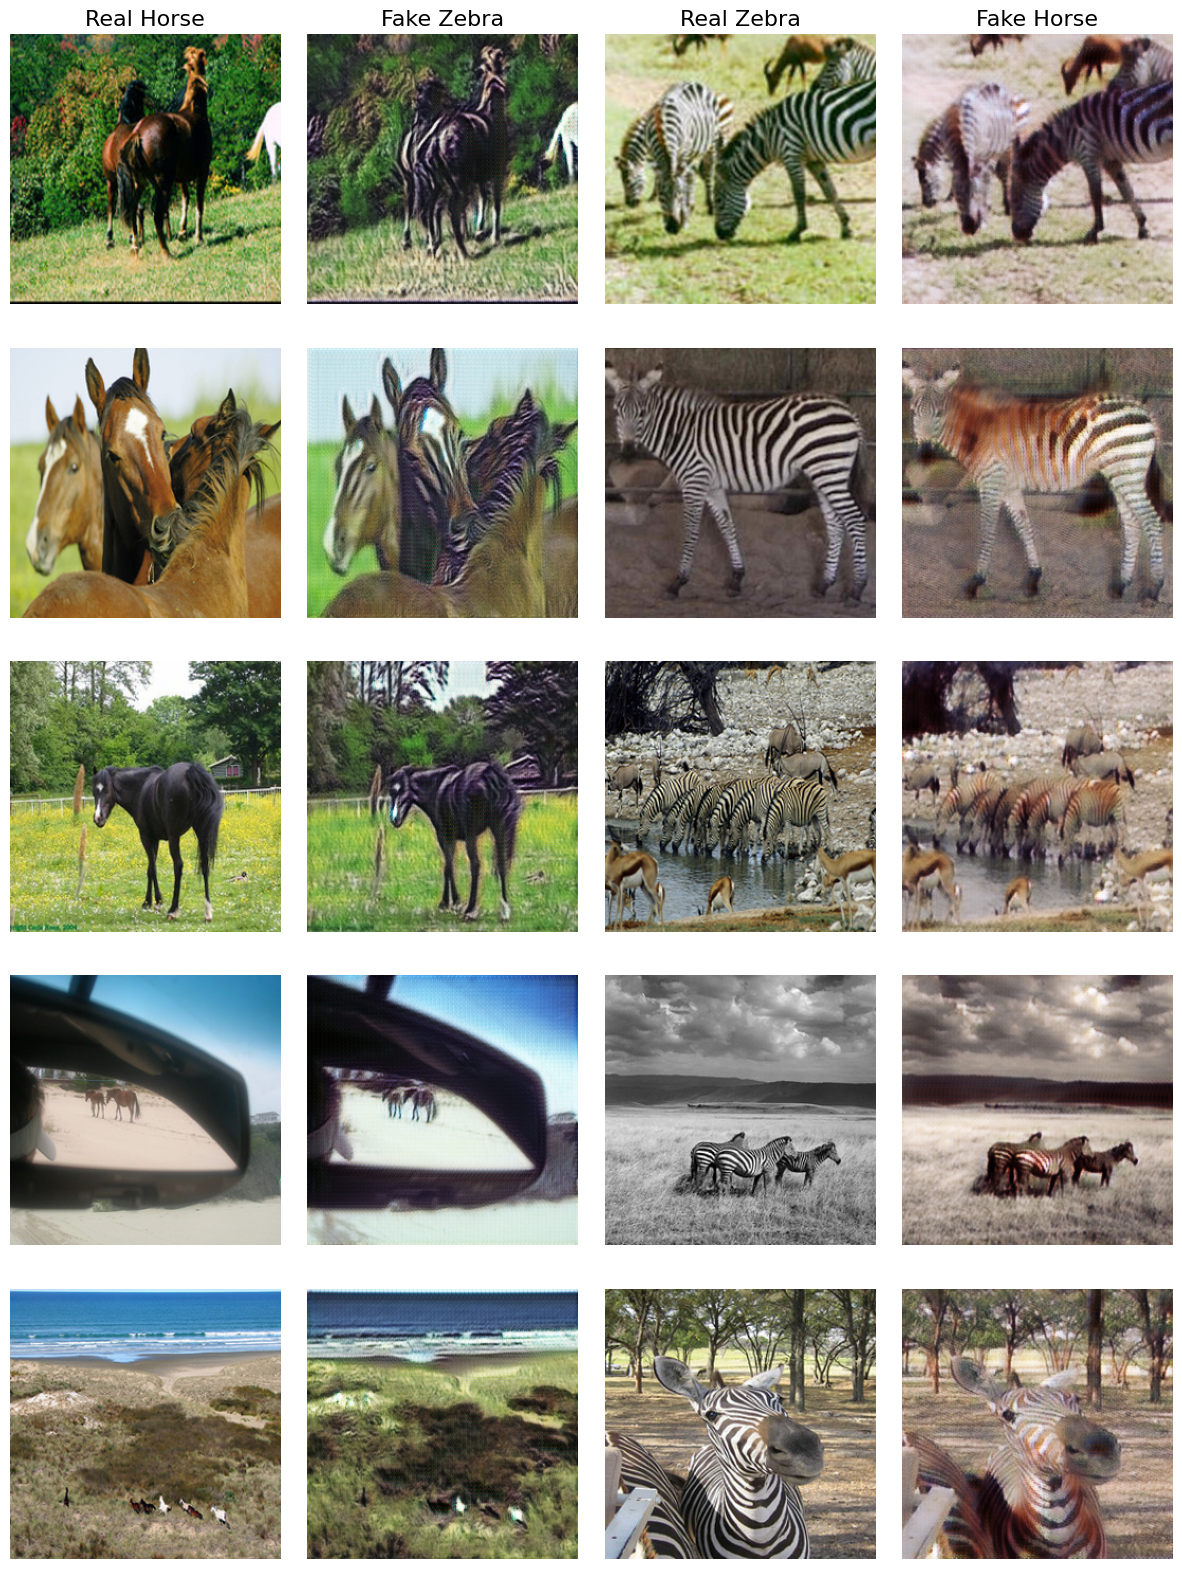

In [ ]:
def unnormalize(tensor):
    # Reverts the [-1, 1] normalization back to [0, 1] for plotting
    return tensor.cpu().detach() * 0.5 + 0.5

# Fetch 5 samples from the test dataloader
batch = next(iter(test_dataloader))
real_A = batch['A'].to(device)
real_B = batch['B'].to(device)

# Generate fakes
fake_B = G_AB(real_A) # Horses to Zebras
fake_A = G_BA(real_B) # Zebras to Horses

fig, axes = plt.subplots(5, 4, figsize=(15, 20))
plt.subplots_adjust(wspace=0.1, hspace=0.1)

col_titles = ['Real Horse', 'Fake Zebra', 'Real Zebra', 'Fake Horse']
for ax, col in zip(axes[0], col_titles):
    ax.set_title(col, fontsize=16)

for i in range(5):
    # Plot Real Horse -> Fake Zebra
    axes[i, 0].imshow(unnormalize(real_A[i]).permute(1, 2, 0))
    axes[i, 0].axis('off')
    axes[i, 1].imshow(unnormalize(fake_B[i]).permute(1, 2, 0))
    axes[i, 1].axis('off')

    # Plot Real Zebra -> Fake Horse
    axes[i, 2].imshow(unnormalize(real_B[i]).permute(1, 2, 0))
    axes[i, 2].axis('off')
    axes[i, 3].imshow(unnormalize(fake_A[i]).permute(1, 2, 0))
    axes[i, 3].axis('off')

plt.show()

Cycle consistency loss:


Ideally if the conversion is occuring properly, when an image is converted from domain A to domain B and back to domain A, the recreated image should look alomost exactly like the real image. This is what cycle consistency loss ensures, that the entire cycle is smooth. It works by penalizing both the generators invloved in the process if the images do not look alike.